# DAU 차트를 봐서는 DAU를 올릴 수 없다 — 유저 세그먼트 분석 실습

DAU 한 줄짜리 그래프로는 신규 유저의 안착도, 헤비 유저의 이탈 징후도, 잠들었던 유저의 부활도
모두 한 점으로 뭉개져 보이지 않습니다. 이 노트북은 유저를 **7개 세그먼트**로 쪼개고,
세그먼트 사이의 **이동(Flow)** 과 비율 지표로 서비스 건강도를 입체적으로 들여다봅니다.

분석은 두 개의 원천 테이블에서 출발합니다.

| 테이블 | 입자 단위 | 역할 |
| :-- | :-- | :-- |
| `user_master` | user_id (유저당 1행) | 유저별 가입(첫 접속) 정보 |
| `user_activity` | user_id × event_date | 유저별 일별 접속 기록 |

- **실습 1.** 두 테이블에서 4개 파생지표(`is_newbie`, `d0_active`, `active_day_count`, `last_active_date`)를 뽑아 7개 세그먼트로 분류합니다.
- **실습 2.** 어제·오늘 두 시점을 한 행에 담은 마트를 만들고 — 분포(Stock) · 전이 행렬(Flow) · 비율 지표(HURR/CURR/Heavy Loss/Light Loss/Reactivation)를 구합니다.
- **실습 3.** 마트를 여러 날 적재해, 30일 전 heavy 유저가 오늘 어디로 흩어졌는지 N일 변화를 추적합니다.

쿼리는 모두 **DuckDB**로 예시 CSV에 직접 실행합니다.

## 0. 준비

아래 셀은 의존성을 설치합니다. 데이터가 없다면 먼저 터미널에서
`python generate_data.py` 를 실행해 예시 데이터를 만들어 주세요
(`data/user_master.csv`, `data/user_activity.csv`).

In [1]:
# 의존성 설치 (이미 설치돼 있으면 빠르게 넘어갑니다)
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# DuckDB 인메모리 연결 하나를 만들어 노트북 전체에서 재사용합니다.
con = duckdb.connect()

SEG_ORDER = ["new", "heavy_active", "light_active",
             "heavy_inactive", "light_inactive", "risk", "dormant"]
TARGET = "2026-05-20"   # 분석 기준일(오늘)

## 실습 1. 4개 파생지표로 7개 세그먼트 분류하기

먼저 두 원천 테이블을 살펴봅니다. `user_master` 는 유저당 한 줄(가입일),
`user_activity` 는 접속한 날마다 한 줄씩 쌓이는 로그입니다.

In [3]:
master = con.execute("SELECT * FROM read_csv_auto('data/user_master.csv')").df()
activity = con.execute("SELECT * FROM read_csv_auto('data/user_activity.csv')").df()
print("user_master  :", master.shape)
print("user_activity:", activity.shape)
master.head()

user_master  : (200, 2)
user_activity: (4650, 2)


,user_id,first_active_date
0,user_001,2026-05-20
1,user_002,2026-05-20
2,user_003,2026-05-20
3,user_004,2026-05-20
4,user_005,2026-05-20


In [4]:
activity.head()

,user_id,event_date
0,user_144,2026-01-27
1,user_144,2026-01-28
2,user_123,2026-01-29
3,user_144,2026-01-29
4,user_032,2026-01-30


이제 두 테이블을 `LEFT JOIN` 한 뒤 유저 단위로 집계해 4개 지표를 만들고,
`CASE WHEN` 한 단계로 7개 세그먼트를 가릅니다.

- `is_newbie` — 오늘이 첫 접속일인가
- `d0_active` — 오늘 접속했는가
- `active_day_count` — 최근 7일 중 며칠 접속했는가
- `last_active_date` — 가장 최근 접속일은 (활동 이력이 없으면 가입일)

> **DuckDB 주의점** — 활동이 한 줄도 없는 유저는 `LEFT JOIN` 결과가 전부 NULL이라
> `count_if(...)` 가 0이 아니라 **NULL**을 돌려줍니다(BigQuery `COUNTIF` 와 다른 점).
> 그래서 `active_day_count` 를 `coalesce(..., 0)` 으로 감싸 0으로 보정했습니다.
> 같은 이유로 활동 0인 유저는 `d0_active` 도 NULL이 되므로,
> 마지막 light_inactive 분기에는 `NOT d0_active` 를 두지 않고 `active_day_count = 0` 만으로 판정합니다.

In [5]:
query = """
-- 4개 파생지표 계산 + 7개 세그먼트 분류 (오늘 시점, 기준일 2026-05-20)
--
-- user_master 와 user_activity 를 LEFT JOIN 한 뒤 유저 단위로 집계해
-- is_newbie / d0_active / active_day_count / last_active_date 4개 지표를 만들고,
-- CASE WHEN 한 단계로 7개 세그먼트로 분류한다.

WITH metrics AS (
  SELECT
    m.user_id,
    -- 1. 오늘 가입한 유저 여부
    (m.first_active_date = DATE '2026-05-20') AS is_newbie,
    -- 2. 오늘 접속 여부
    bool_or(a.event_date = DATE '2026-05-20') AS d0_active,
    -- 3. 최근 7일(기준일 포함) 접속 일수. 활동이 없으면 count_if 가 NULL 이므로 0 으로 보정.
    coalesce(count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 6 DAY
                                       AND DATE '2026-05-20'), 0) AS active_day_count,
    -- 4. 마지막 활동일. 활동 이력이 없으면 가입일을 마지막 활동일로 간주.
    coalesce(max(CASE WHEN a.event_date <= DATE '2026-05-20' THEN a.event_date END),
             m.first_active_date) AS last_active_date
  FROM read_csv_auto('data/user_master.csv') m
  LEFT JOIN read_csv_auto('data/user_activity.csv') a USING (user_id)
  GROUP BY m.user_id, m.first_active_date
)
SELECT
  user_id,
  CASE
    WHEN is_newbie                                                        THEN 'new'
    WHEN d0_active     AND active_day_count >= 5                          THEN 'heavy_active'
    WHEN d0_active     AND active_day_count BETWEEN 1 AND 4               THEN 'light_active'
    WHEN NOT d0_active AND active_day_count >= 5                          THEN 'heavy_inactive'
    WHEN NOT d0_active AND active_day_count BETWEEN 1 AND 4               THEN 'light_inactive'
    -- 활동이 전혀 없는 유저는 d0_active 가 NULL 이므로 NOT d0_active 조건을 두지 않는다.
    WHEN active_day_count = 0
         AND last_active_date >  DATE '2026-05-20' - INTERVAL 6 DAY      THEN 'light_inactive'
    WHEN active_day_count = 0
         AND last_active_date BETWEEN DATE '2026-05-20' - INTERVAL 30 DAY
                                  AND DATE '2026-05-20' - INTERVAL 6 DAY THEN 'risk'
    WHEN active_day_count = 0
         AND last_active_date <  DATE '2026-05-20' - INTERVAL 30 DAY     THEN 'dormant'
  END AS user_seg
FROM metrics
ORDER BY user_id;
"""
seg = con.execute(query).df()
print(seg["user_seg"].value_counts().reindex(SEG_ORDER))

user_seg
new               10
heavy_active      30
light_active      30
heavy_inactive     9
light_inactive    48
risk              53
dormant           20
Name: count, dtype: int64


7개 세그먼트가 모두 등장하도록 각 세그먼트에서 한 명씩 뽑아 보면, 4개 지표가
어떻게 하나의 세그먼트로 압축되는지 한눈에 들어옵니다.

In [6]:
# 각 세그먼트의 대표 유저를 한 명씩 발췌
sample = seg.groupby("user_seg").first().reindex(SEG_ORDER).reset_index()
sample[["user_seg", "user_id"]]

,user_seg,user_id
0,new,user_001
1,heavy_active,user_017
2,light_active,user_016
3,heavy_inactive,user_022
4,light_inactive,user_011
5,risk,user_021
6,dormant,user_026


## 실습 2. 어제·오늘 마트 → 분포·전이·KPI

한 시점의 분포(Stock)만으로는 "heavy가 어제와 같은 30명이라도, 그대로 남은 30명인지
빠진 자리를 다른 유저가 채운 건지"를 구별할 수 없습니다. 그 변화(Flow)를 보려면
**어제와 오늘 두 시점의 세그먼트를 한 행에 나란히 담은 마트**가 필요합니다.

아래 쿼리는 4개 지표를 오늘·어제 두 시점으로 계산해 `user_seg`(오늘)와
`user_seg_from`(어제)을 한 행에 담고, 그 결과를 `mart_user_segment` 테이블로 적재합니다.

In [7]:
build_mart_query = """
-- 유저 세그먼트 마트 생성 (mart_user_segment)
--
-- 두 원천 CSV에서 4개 파생지표를 '오늘'과 '어제' 두 시점으로 계산하고,
-- 각 시점을 7개 세그먼트로 분류해 한 행에 user_seg(오늘) / user_seg_from(어제)으로 담는다.
-- 기준일(target_date)은 2026-05-20.
--
-- DuckDB 주의점: 활동 기록이 한 줄도 없는 유저는 LEFT JOIN 결과가 전부 NULL이라
--   count_if(...) 가 0이 아니라 NULL 을 돌려준다(BigQuery COUNTIF 와 다른 점).
--   그래서 active_day_count 를 coalesce(..., 0) 으로 감싸 0 으로 보정한다.

CREATE OR REPLACE TABLE mart_user_segment AS
WITH metrics AS (
  SELECT
    m.user_id,

    -- [오늘 시점 지표]
    (m.first_active_date = DATE '2026-05-20') AS is_newbie,
    bool_or(a.event_date = DATE '2026-05-20') AS d0_active,
    coalesce(count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 6 DAY
                                       AND DATE '2026-05-20'), 0) AS active_day_count,
    coalesce(max(CASE WHEN a.event_date <= DATE '2026-05-20' THEN a.event_date END),
             m.first_active_date) AS last_active_date,

    -- [어제 시점 지표] (윈도우를 하루씩 미룬다)
    (m.first_active_date = DATE '2026-05-20' - INTERVAL 1 DAY) AS is_newbie_from,
    bool_or(a.event_date = DATE '2026-05-20' - INTERVAL 1 DAY) AS d0_active_from,
    coalesce(count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 7 DAY
                                       AND DATE '2026-05-20' - INTERVAL 1 DAY), 0) AS active_day_count_from,
    -- 어제 이전에 이미 가입한 유저만 가입일로 보정한다.
    -- 오늘 막 가입한 신규는 어제 존재하지 않았으므로 NULL 로 남겨 user_seg_from 이 NULL 이 되게 한다.
    coalesce(max(CASE WHEN a.event_date <= DATE '2026-05-20' - INTERVAL 1 DAY THEN a.event_date END),
             CASE WHEN m.first_active_date <= DATE '2026-05-20' - INTERVAL 1 DAY
                  THEN m.first_active_date END) AS last_active_date_from
  FROM read_csv_auto('data/user_master.csv') m
  LEFT JOIN read_csv_auto('data/user_activity.csv') a USING (user_id)
  GROUP BY m.user_id, m.first_active_date
)
SELECT
  DATE '2026-05-20' AS target_date,
  user_id,

  -- [어제 시점 분류]
  CASE
    WHEN is_newbie_from                                                          THEN 'new'
    WHEN d0_active_from     AND active_day_count_from >= 5                        THEN 'heavy_active'
    WHEN d0_active_from     AND active_day_count_from BETWEEN 1 AND 4             THEN 'light_active'
    WHEN NOT d0_active_from AND active_day_count_from >= 5                        THEN 'heavy_inactive'
    WHEN NOT d0_active_from AND active_day_count_from BETWEEN 1 AND 4             THEN 'light_inactive'
    WHEN active_day_count_from = 0
         AND last_active_date_from >  DATE '2026-05-20' - INTERVAL 7 DAY         THEN 'light_inactive'
    WHEN active_day_count_from = 0
         AND last_active_date_from BETWEEN DATE '2026-05-20' - INTERVAL 31 DAY
                                       AND DATE '2026-05-20' - INTERVAL 7 DAY    THEN 'risk'
    WHEN active_day_count_from = 0
         AND last_active_date_from <  DATE '2026-05-20' - INTERVAL 31 DAY        THEN 'dormant'
  END AS user_seg_from,

  -- [오늘 시점 분류]
  CASE
    WHEN is_newbie                                                          THEN 'new'
    WHEN d0_active     AND active_day_count >= 5                            THEN 'heavy_active'
    WHEN d0_active     AND active_day_count BETWEEN 1 AND 4                 THEN 'light_active'
    WHEN NOT d0_active AND active_day_count >= 5                            THEN 'heavy_inactive'
    WHEN NOT d0_active AND active_day_count BETWEEN 1 AND 4                 THEN 'light_inactive'
    -- 활동이 전혀 없는 유저는 d0_active 가 NULL 이므로 NOT d0_active 조건을 두지 않는다.
    -- active_day_count = 0 이면 오늘 접속이 없다는 뜻이라 d0 조건은 어차피 불필요하다.
    WHEN active_day_count = 0
         AND last_active_date >  DATE '2026-05-20' - INTERVAL 6 DAY        THEN 'light_inactive'
    WHEN active_day_count = 0
         AND last_active_date BETWEEN DATE '2026-05-20' - INTERVAL 30 DAY
                                  AND DATE '2026-05-20' - INTERVAL 6 DAY   THEN 'risk'
    WHEN active_day_count = 0
         AND last_active_date <  DATE '2026-05-20' - INTERVAL 30 DAY       THEN 'dormant'
  END AS user_seg
FROM metrics
ORDER BY user_id;
"""
con.execute(build_mart_query)
mart = con.execute("SELECT * FROM mart_user_segment ORDER BY user_id").df()
print("mart rows:", len(mart))
mart.head()

mart rows: 200


,target_date,user_id,user_seg_from,user_seg
0,2026-05-20,user_001,NaN,new
1,2026-05-20,user_002,NaN,new
2,2026-05-20,user_003,NaN,new
3,2026-05-20,user_004,NaN,new
4,2026-05-20,user_005,NaN,new


### Stock — 일별 세그먼트 분포

단순한 `GROUP BY` 한 번이면 한 시점의 분포가 나옵니다.

,user_seg,users
0,new,10
1,heavy_active,30
2,light_active,30
3,heavy_inactive,9
4,light_inactive,48
5,risk,53
6,dormant,20


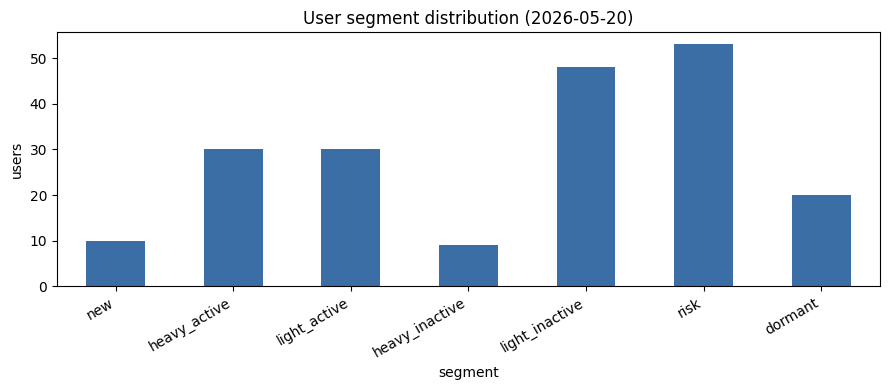

In [8]:
query = """
-- 일별 세그먼트 분포 (Stock)
-- build_mart.sql 로 mart_user_segment 를 먼저 만들어 두어야 한다.

SELECT
  user_seg,
  count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20'
GROUP BY user_seg
ORDER BY array_position(
  ['new', 'heavy_active', 'light_active', 'heavy_inactive', 'light_inactive', 'risk', 'dormant'],
  user_seg);
"""
dist = con.execute(query).df()
display(dist)

ax = (dist.set_index("user_seg").reindex(SEG_ORDER)["users"]
        .plot.bar(figsize=(9, 4), color="#3b6ea5"))
ax.set_title("User segment distribution (2026-05-20)")
ax.set_xlabel("segment"); ax.set_ylabel("users")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

### Flow — 세그먼트 전이 행렬

어제(`user_seg_from`)를 행, 오늘(`user_seg`)을 열로 펼치면 전이 행렬이 됩니다.
대각선은 그대로 유지된 유저, 대각선 위쪽(오른쪽)은 활동성이 떨어진 유저,
아래쪽(왼쪽)은 활동성이 높아진 유저입니다.

user_seg,heavy_active,light_active,heavy_inactive,light_inactive,risk,dormant
user_seg_from,,,,,,
heavy_active,21,0,9,1,0,0
light_active,2,8,0,16,0,0
heavy_inactive,6,0,0,2,0,0
light_inactive,1,21,0,29,4,0
risk,0,1,0,0,49,1
dormant,0,0,0,0,0,19


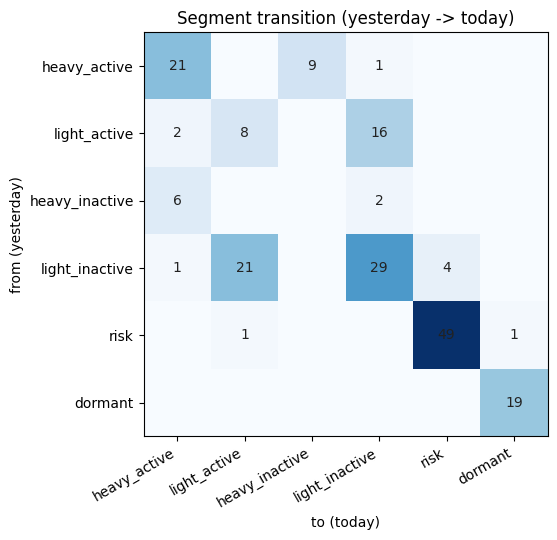

In [9]:
query = """
-- 세그먼트 전이 (Flow): 어제(user_seg_from) -> 오늘(user_seg)
-- build_mart.sql 로 mart_user_segment 를 먼저 만들어 두어야 한다.

SELECT
  user_seg_from,
  user_seg,
  count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20'
  AND user_seg_from IS NOT NULL   -- 오늘 처음 가입한 신규(어제 NULL)는 별도 분석
  AND user_seg_from <> 'new'      -- 어제 막 가입한 신규도 전이 분석에서는 제외
GROUP BY user_seg_from, user_seg
ORDER BY user_seg_from, user_seg;
"""
trans = con.execute(query).df()

order = ["heavy_active", "light_active", "heavy_inactive", "light_inactive", "risk", "dormant"]
pivot = (trans.pivot(index="user_seg_from", columns="user_seg", values="users")
              .reindex(index=order, columns=order))
display(pivot.fillna(0).astype(int))

m = pivot.values.astype(float)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(np.nan_to_num(m), cmap="Blues")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_xlabel("to (today)"); ax.set_ylabel("from (yesterday)")
for i in range(len(order)):
    for j in range(len(order)):
        v = m[i, j]
        if not np.isnan(v):
            ax.text(j, i, int(v), ha="center", va="center", color="#222")
ax.set_title("Segment transition (yesterday -> today)")
plt.tight_layout(); plt.show()

### 비율 지표 (KPI)

전이 행렬에서 의미 있는 비율을 뽑으면 그대로 KPI가 됩니다.
`heavy = {heavy_active, heavy_inactive}`, `light = {light_active, light_inactive}` 로 묶었습니다.

- **HURR** — heavy 유지율 · **CURR** — heavy+light(핵심 활동층) 유지율
- **Heavy Loss** — heavy → light 강등 · **Light Loss** — light → risk 이탈
- **Reactivation** — risk → light 복귀

In [10]:
query = """
-- 세그먼트 전이 기반 비율 지표 5종
--   HURR        : heavy(활성+비활성)를 유지하는 비율
--   CURR        : heavy+light(핵심 활동 유저층)를 유지하는 비율
--   Heavy Loss  : heavy 유저가 light 로 떨어진 비율
--   Light Loss  : light 유저가 위험 구간(risk)으로 이탈한 비율
--   Reactivation: 위험(risk) 유저가 다시 light 로 돌아온 비율
--
-- heavy = {heavy_active, heavy_inactive}, light = {light_active, light_inactive}
-- 0 으로 나누는 것을 막기 위해 분모를 nullif(..., 0) 으로 감싼다.

SELECT
  round(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive')
                 AND user_seg  IN ('heavy_active', 'heavy_inactive'))
        / nullif(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive')), 0) * 100, 1) AS hurr_pct,

  round(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive', 'light_active', 'light_inactive')
                 AND user_seg  IN ('heavy_active', 'heavy_inactive', 'light_active', 'light_inactive'))
        / nullif(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive', 'light_active', 'light_inactive')), 0) * 100, 1) AS curr_pct,

  round(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive')
                 AND user_seg  IN ('light_active', 'light_inactive'))
        / nullif(count_if(user_seg_from IN ('heavy_active', 'heavy_inactive')), 0) * 100, 1) AS heavy_loss_pct,

  round(count_if(user_seg_from IN ('light_active', 'light_inactive') AND user_seg = 'risk')
        / nullif(count_if(user_seg_from IN ('light_active', 'light_inactive')), 0) * 100, 1) AS light_loss_pct,

  round(count_if(user_seg_from = 'risk' AND user_seg IN ('light_active', 'light_inactive'))
        / nullif(count_if(user_seg_from = 'risk'), 0) * 100, 1) AS reactivation_pct
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20';
"""
kpi = con.execute(query).df()
kpi.T.rename(columns={0: "pct"})

,pct
hurr_pct,92.3
curr_pct,96.7
heavy_loss_pct,7.7
light_loss_pct,4.9
reactivation_pct,2.0


## 실습 3. N일 후 세그먼트 변화 추적

1일 단위 변화는 폭이 작아 패턴이 잘 안 보입니다(어제 heavy가 오늘도 heavy일 확률이 높으니까요).
시간 축을 길게 잡아 **30일 전 heavy 유저가 오늘 어디에 있는지** 보면 훨씬 또렷한 그림이 나옵니다.

이를 위해 앞서 만든 마트 쿼리를 **기준일만 바꿔 가며 여러 날 적재**합니다.
운영 환경에서 마트가 매일 쌓이는 것을 그대로 흉내 내는 셈입니다.

In [11]:
# 실습 2의 마트 쿼리를 기준일만 바꿔 2026-04-20 ~ 2026-05-20 (31일) 적재한다.
# (실습 2에서 하루치만 만들었던 mart_user_segment 를 여러 날치로 다시 채운다.)
con.execute("DROP TABLE IF EXISTS mart_user_segment")
for i, t in enumerate(pd.date_range(end=TARGET, periods=31)):
    ts = t.date().isoformat()
    q = build_mart_query.replace("2026-05-20", ts)
    if i > 0:
        q = q.replace("CREATE OR REPLACE TABLE mart_user_segment AS",
                      "INSERT INTO mart_user_segment BY NAME")
    con.execute(q)

print(con.execute(
    "SELECT count(DISTINCT target_date) AS n_days, count(*) AS n_rows FROM mart_user_segment"
).df())

   n_days  n_rows
0      31    6200


이제 두 시점(30일 전 · 오늘)을 `user_id` 로 self-join 하면, 30일 전 heavy 유저가
오늘 어느 세그먼트로 흩어졌는지가 한 표로 나옵니다.

,seg_30days_ago,seg_today,users,pct
0,heavy_active,heavy_active,21,52.5
1,heavy_active,risk,8,20.0
2,heavy_active,light_inactive,5,12.5
3,heavy_active,light_active,4,10.0
4,heavy_active,heavy_inactive,2,5.0


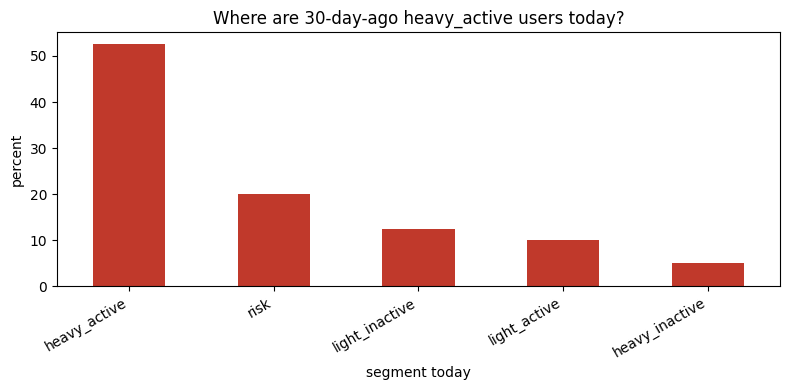

In [12]:
query = """
-- N일 후 세그먼트 변화 추적: 30일 전 heavy_active 였던 유저가 오늘은 어디에 있는가
--
-- 1일 단위 전이는 변화 폭이 작아 패턴이 잘 안 보이지만, 시간 축을 길게 잡으면
-- 누적된 이동이 또렷하게 드러난다. mart_user_segment 가 여러 날짜에 걸쳐
-- 적재돼 있다는 전제 하에, 두 시점(과거·오늘)을 user_id 로 self-join 한다.
-- (past.user_seg 를 'new' 로 바꾸면 신규 유저의 N일 안착 패턴을 볼 수 있다.)

SELECT
  past.user_seg AS seg_30days_ago,
  curr.user_seg AS seg_today,
  count(*) AS users,
  round(count(*) / sum(count(*)) OVER () * 100, 1) AS pct
FROM mart_user_segment AS past
LEFT JOIN mart_user_segment AS curr
  ON past.user_id = curr.user_id
 AND curr.target_date = DATE '2026-05-20'
WHERE past.target_date = DATE '2026-05-20' - INTERVAL 30 DAY
  AND past.user_seg = 'heavy_active'
GROUP BY 1, 2
ORDER BY users DESC;
"""
nday = con.execute(query).df()
display(nday)

ax = nday.set_index("seg_today")["pct"].plot.bar(figsize=(8, 4), color="#c0392b")
ax.set_title("Where are 30-day-ago heavy_active users today?")
ax.set_xlabel("segment today"); ax.set_ylabel("percent")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

같은 쿼리에서 `past.user_seg` 를 `'new'` 로 바꾸면 **30일 전 가입한 신규 유저가
오늘 어디에 있는가**(N-day Activation/Retention)를, `n_days` 에 해당하는 날짜 간격을
7·14·60·90 으로 바꾸면 다른 시간 축의 변화를 곧바로 볼 수 있습니다.

매일 적재된 마트 한 장으로 단기 KPI(실습 2)부터 N일 누적 변화(실습 3)까지
같은 구조 위에서 뽑아낼 수 있다는 것이 이 마트의 힘입니다.